<a href="https://colab.research.google.com/github/pulindu-seniya-silva/ASAS_FDM/blob/Random_Forest_Pulindu_V2/Random_Forest_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Pre-processing

Importing relevent libraries

Importing dataset

Keeping save copies of the dataset

In [2]:
import os, re, json
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from scipy import sparse
import joblib

from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    accuracy_score, recall_score, balanced_accuracy_score
)

CSV_PATH = "Road Accident Data.csv"   # drag and drop dataset directly to the files in colab and keep this as it is
OUTDIR   = "artifacts"
TEST_SIZE = 0.20
RANDOM_STATE = 42

os.makedirs(OUTDIR, exist_ok=True)

# load and keep a safe raw copy
df_in  = pd.read_csv(CSV_PATH)
df_raw = df_in.copy(deep=True)   # audit/rollback
df     = df_in.copy(deep=True)   # working copy

print("Loaded:", df.shape)
print("Dataset:")
df.head(5)

def evaluate(y_true, y_pred, title=""):
    print(f"\n=== {title} ===")
    print("Macro F1:       ", round(f1_score(y_true, y_pred, average="macro"), 4))
    print("Recall (macro): ", round(recall_score(y_true, y_pred, average="macro"), 4))
    print("Balanced Acc:   ", round(balanced_accuracy_score(y_true, y_pred), 4))
    print("\nClassification report:\n", classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred, labels=np.unique(y_true))
    cm_norm = (cm.T / cm.sum(axis=1, where=cm.sum(axis=1)!=0)).T  # safe normalize
    print("Confusion matrix (row-normalized):\n", np.round(cm_norm, 3))

Loaded: (4637, 21)
Dataset:


<Axes: xlabel='Accident_Severity'>

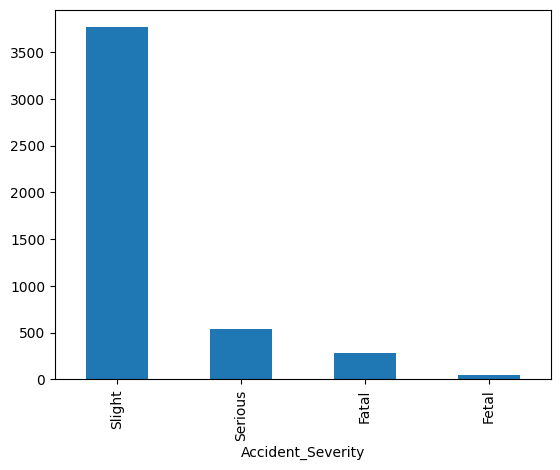

In [3]:
#plot severity classes in a bar char
df['Accident_Severity'].value_counts().plot(kind='bar')

drop purely irrelevant columns early

In [4]:
early_drop = [c for c in [
    "Accident_Index",
] if c in df.columns]

df = df.drop(columns=early_drop, errors="ignore")
print("After early drop:", df.shape)
print("Dropped:", early_drop)


After early drop: (4637, 20)
Dropped: ['Accident_Index']


Implimenting string hygene utils

In [5]:
def strip_collapse(s):
    if pd.isna(s): return s
    return re.sub(r"\s+", " ", str(s).strip())

def map_values(series, mapping):
    return series.replace(mapping)

def bucket_rare(series, min_count=100, other_label="Other"):
    vc = series.value_counts(dropna=False)
    rare = vc[vc < min_count].index
    return series.where(~series.isin(rare), other_label)

# trim whitespace on all object columns to avoid duplicate labels
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].apply(strip_collapse)


**Basic cleaning**

- Fix tatget label typos and remove missing values

In [6]:
if "Accident_Severity" in df.columns:
    df["Accident_Severity"] = df["Accident_Severity"].astype("object")
    # from your counts: "Fetal" is a typo
    df["Accident_Severity"] = map_values(df["Accident_Severity"],
                                         {"Fetal": "Fatal", "fetal": "Fatal"})
    before = df.shape[0]
    df = df[~df["Accident_Severity"].isna()].copy()
    print("Dropped rows with missing Accident_Severity:", before - df.shape[0])


Dropped rows with missing Accident_Severity: 0


In [7]:
df["Accident_Severity"] = df["Accident_Severity"].replace({
    "Fatal": "Severe",
    "Serious": "Severe",
    "Slight": "Slight"
})


<Axes: xlabel='Accident_Severity'>

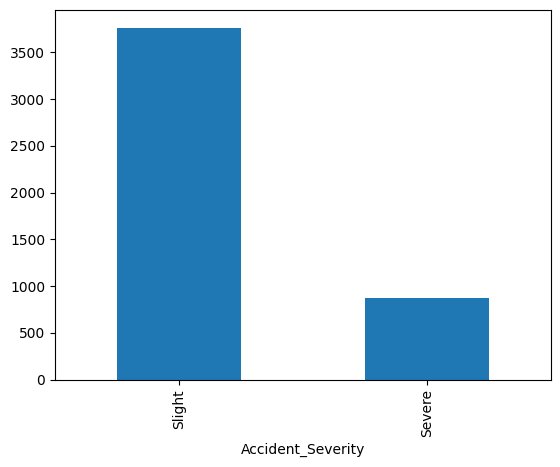

In [8]:
df['Accident_Severity'].value_counts().plot(kind='bar')

- parse "accident_date" and recompute "Day_of_Week"

In [9]:
if "Accident Date" in df.columns:
    df["Accident Date"] = pd.to_datetime(df["Accident Date"], errors="coerce", dayfirst=True)
    print("Unparseable dates:", df["Accident Date"].isna().sum())

    # recompute Day_of_Week from parsed date (consistent + fixes 1 NaN)
    df["Day_of_Week"] = df["Accident Date"].dt.day_name()


Unparseable dates: 2774


- normalize "Time" to HH:MM and flag invalid

In [10]:
if "Time" in df.columns:
    def normalize_time(x):
        if pd.isna(x): return np.nan
        s = str(x).strip()
        m = re.match(r"^(\d{1,2}):(\d{2})$", s)
        if not m: return np.nan
        hh, mm = int(m.group(1)), int(m.group(2))
        if 0 <= hh <= 23 and 0 <= mm <= 59:
            return f"{hh:02d}:{mm:02d}"
        return np.nan

    df["Time"] = df["Time"].apply(normalize_time)
    print("Invalid/NaN times:", df["Time"].isna().sum())


Invalid/NaN times: 1


- Harmonize "unknown" values and shorten long labels

In [11]:
# unify explicit "Unknown" labels
if "Junction_Control" in df.columns:
    df["Junction_Control"] = map_values(df["Junction_Control"],
                                        {"Data missing or out of range": "Unknown"})

if "Junction_Detail" in df.columns:
    df["Junction_Detail"] = map_values(df["Junction_Detail"],
                                       {"Not at junction or within 20 metres": "Not at junction"})

# fill NaN -> "Unknown" for key categoricals
for col in ["Light_Conditions","Weather_Conditions","Road_Surface_Conditions",
            "Road_Type","Junction_Control","Junction_Detail",
            "Urban_or_Rural_Area"]:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

# Compact some verbose labels (optional but cleaner for OHE and plots)
if "Light_Conditions" in df.columns:
    df["Light_Conditions"] = map_values(df["Light_Conditions"], {
        "Darkness - lights lit": "Dark_lit",
        "Darkness - lights unlit": "Dark_unlit",
        "Darkness - no lighting": "Dark_none",
        "Darkness - lighting unknown": "Dark_unknown",
    })

if "Weather_Conditions" in df.columns:
    df["Weather_Conditions"] = map_values(df["Weather_Conditions"], {
        "Fine + high winds": "Fine_high_winds",
        "Raining + high winds": "Rain_high_winds",
        "Raining no high winds": "Rain_no_high",
        "Snowing + high winds": "Snow_high_winds",
        "Snowing no high winds": "Snow_no_high",
        "Fog or mist": "Fog_mist",
        "Fine no high winds": "Fine_no_high",
    })

if "Road_Surface_Conditions" in df.columns:
    df["Road_Surface_Conditions"] = map_values(df["Road_Surface_Conditions"],
                                               {"Flood over 3cm. deep": "Flood_3cm_plus"})


In [12]:
df.head(5)

,Accident Date,Day_of_Week,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Carriageway_Hazards,Longitude,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,2021-01-01,Friday,Give way or uncontrolled,T or staggered junction,Severe,51.512273,Daylight,Kensington and Chelsea,NaN,-0.201349,1,2,Metropolitan Police,Dry,One way street,30.0,15:11,Urban,Fine_no_high,Car
1,2021-01-05,Tuesday,Give way or uncontrolled,Crossroads,Severe,51.514399,Daylight,Kensington and Chelsea,NaN,-0.199248,11,2,Metropolitan Police,Wet or damp,Single carriageway,30.0,10:59,Urban,Fine_no_high,Taxi/Private hire car
2,2021-01-04,Monday,Give way or uncontrolled,T or staggered junction,Slight,51.486668,Daylight,Kensington and Chelsea,NaN,-0.179599,1,2,Metropolitan Police,Dry,Single carriageway,30.0,14:19,Urban,Fine_no_high,Taxi/Private hire car
3,2021-01-05,Tuesday,Auto traffic signal,T or staggered junction,Severe,51.507804,Daylight,Kensington and Chelsea,NaN,-0.203110,1,2,Metropolitan Police,Frost or ice,Single carriageway,30.0,08:10,Urban,Other,Motorcycle over 500cc
4,2021-01-06,Wednesday,Auto traffic signal,Crossroads,Severe,51.482076,Dark_lit,Kensington and Chelsea,NaN,-0.173445,1,2,Metropolitan Police,Dry,Single carriageway,30.0,17:25,Urban,Fine_no_high,Car


**Feature engineering**

In [13]:
# Time_of_Day from Time
if "Time" in df.columns:
    def time_bucket(t):
        if pd.isna(t): return "Unknown"
        hh = int(t.split(":")[0])
        if 5 <= hh < 11:  return "Morning"
        if 11 <= hh < 16: return "Afternoon"
        if 16 <= hh < 20: return "Evening"
        return "Night"
    df["Time_of_Day"] = df["Time"].apply(time_bucket)

# Month / Season / Day_name from Accident Date
if "Accident Date" in df.columns:
    df["Month"] = df["Accident Date"].dt.month
    def season(m):
        if m in [12,1,2]:  return "Winter"
        if m in [3,4,5]:   return "Spring"
        if m in [6,7,8]:   return "Summer"
        if m in [9,10,11]: return "Autumn"
        return "Unknown"
    df["Season"]   = df["Month"].apply(season)
    df["Day_name"] = df["Accident Date"].dt.day_name()

# High speed flag
if "Speed_limit" in df.columns:
    df["High_Speed"] = (pd.to_numeric(df["Speed_limit"], errors="coerce") >= 60).astype(int)


In [14]:
df.head()

,Accident Date,Day_of_Week,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Carriageway_Hazards,Longitude,...,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type,Time_of_Day,Month,Season,Day_name,High_Speed
0,2021-01-01,Friday,Give way or uncontrolled,T or staggered junction,Severe,51.512273,Daylight,Kensington and Chelsea,NaN,-0.201349,...,30.0,15:11,Urban,Fine_no_high,Car,Afternoon,1.0,Winter,Friday,0
1,2021-01-05,Tuesday,Give way or uncontrolled,Crossroads,Severe,51.514399,Daylight,Kensington and Chelsea,NaN,-0.199248,...,30.0,10:59,Urban,Fine_no_high,Taxi/Private hire car,Morning,1.0,Winter,Tuesday,0
2,2021-01-04,Monday,Give way or uncontrolled,T or staggered junction,Slight,51.486668,Daylight,Kensington and Chelsea,NaN,-0.179599,...,30.0,14:19,Urban,Fine_no_high,Taxi/Private hire car,Afternoon,1.0,Winter,Monday,0
3,2021-01-05,Tuesday,Auto traffic signal,T or staggered junction,Severe,51.507804,Daylight,Kensington and Chelsea,NaN,-0.203110,...,30.0,08:10,Urban,Other,Motorcycle over 500cc,Morning,1.0,Winter,Tuesday,0
4,2021-01-06,Wednesday,Auto traffic signal,Crossroads,Severe,51.482076,Dark_lit,Kensington and Chelsea,NaN,-0.173445,...,30.0,17:25,Urban,Fine_no_high,Car,Evening,1.0,Winter,Wednesday,0


**Enforce numeric dtypes and quick sanity report**

In [15]:
for c in ["Speed_limit","Number_of_Vehicles","Number_of_Casualties","Month"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

print("\n=== Post-cleaning snapshot ===")
cols_to_peek = ["Accident_Severity","Day_of_Week","Light_Conditions","Weather_Conditions",
                "Road_Surface_Conditions","Road_Type","Junction_Control","Junction_Detail",
                "Urban_or_Rural_Area"]
for col in cols_to_peek:
    if col in df.columns:
        print(f"{col}: {df[col].nunique()} unique")
        print(df[col].value_counts(dropna=False).head(5).to_dict(), "\n")



=== Post-cleaning snapshot ===
Accident_Severity: 2 unique
{'Slight': 3765, 'Severe': 872} 

Day_of_Week: 7 unique
{nan: 2774, 'Thursday': 325, 'Saturday': 315, 'Friday': 313, 'Wednesday': 280} 

Light_Conditions: 5 unique
{'Daylight': 3336, 'Dark_lit': 1284, 'Dark_unknown': 7, 'Dark_unlit': 6, 'Dark_none': 4} 

Weather_Conditions: 9 unique
{'Fine_no_high': 4019, 'Rain_no_high': 459, 'Other': 51, 'Snow_no_high': 32, 'Fine_high_winds': 25} 

Road_Surface_Conditions: 5 unique
{'Dry': 3775, 'Wet or damp': 803, 'Frost or ice': 33, 'Snow': 25, 'We': 1} 

Road_Type: 6 unique
{'Single carriageway': 3880, 'Dual carriageway': 478, 'One way street': 177, 'Roundabout': 95, 'Slip road': 6} 

Junction_Control: 5 unique
{'Give way or uncontrolled': 2329, 'Auto traffic signal': 1372, 'Unknown': 927, 'Stop sign': 5, 'Authorised person': 4} 

Junction_Detail: 9 unique
{'T or staggered junction': 2201, 'Crossroads': 1210, 'Not at junction': 927, 'Roundabout': 101, 'Private drive or entrance': 79} 

Urb

**Definiing input(x) and target(y) features**

In [16]:
assert "Accident_Severity" in df.columns
y = df["Accident_Severity"].astype("category")

candidate_X = [
    "Day_name","Time_of_Day","Month","Season",
    "Weather_Conditions","Light_Conditions","Road_Surface_Conditions",
    "Road_Type","Junction_Detail","Junction_Control",
    "Urban_or_Rural_Area","Speed_limit","High_Speed",
    "Vehicle_Type","Carriageway_Hazards",
    "Local_Authority_(District)","Police_Force",
    "Latitude","Longitude"
]
X_cols = [c for c in candidate_X if c in df.columns]
X = df[X_cols].copy()


assert "Number_of_Casualties" not in X.columns
assert "Accident_Severity" not in X.columns

print("X (classification):", X_cols)
print("y distribution:\n", y.value_counts(normalize=True).round(3))


X (classification): ['Day_name', 'Time_of_Day', 'Month', 'Season', 'Weather_Conditions', 'Light_Conditions', 'Road_Surface_Conditions', 'Road_Type', 'Junction_Detail', 'Junction_Control', 'Urban_or_Rural_Area', 'Speed_limit', 'High_Speed', 'Vehicle_Type', 'Carriageway_Hazards', 'Local_Authority_(District)', 'Police_Force', 'Latitude', 'Longitude']
y distribution:
 Accident_Severity
Slight    0.812
Severe    0.188
Name: proportion, dtype: float64


In [17]:
# Example: discretize lat/lon
df["Lat_bin"] = (df["Latitude"] // 0.01) * 0.01
df["Lon_bin"] = (df["Longitude"] // 0.01) * 0.01


**Split x and y and stratify bt class**

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)


**Building preprocessors**

In [19]:
from sklearn.impute import SimpleImputer

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X_cols if c not in cat_cols]

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

num_pipe_linear = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

num_pipe_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

preproc_linear = ColumnTransformer(
    transformers=[
        ("cat", cat_pipe, cat_cols),
        ("num", num_pipe_linear, num_cols),
    ],
    remainder="drop"
)

preproc_tree = ColumnTransformer(
    transformers=[
        ("cat", cat_pipe, cat_cols),
        ("num", num_pipe_tree, num_cols),
    ],
    remainder="drop"
)

**Fit and transform**

In [20]:
preproc_linear.fit(X_train)
preproc_tree.fit(X_train)

#For linear classification models
Xtr_lin = preproc_linear.transform(X_train)
Xte_lin = preproc_linear.transform(X_test)

#for tree classification models
Xtr_tree = preproc_tree.transform(X_train)
Xte_tree = preproc_tree.transform(X_test)

print("Linear shapes:", Xtr_lin.shape, Xte_lin.shape)
print("Tree shapes:  ", Xtr_tree.shape, Xte_tree.shape)

Linear shapes: (3709, 96) (928, 96)
Tree shapes:   (3709, 96) (928, 96)


# Implementation of Synthetic Minor Oversampling Technique(SMOTE) to solve Class **imbalance**

In [21]:
# === SMOTE to fix class imbalance (run after preprocessing) ===
# Uses imblearn. If not installed in Colab: `pip install -q imblearn`

import numpy as np
from scipy import sparse
from imblearn.over_sampling import SMOTE
from collections import Counter

def _to_dense_if_sparse(X):
    """SMOTE requires dense in many setups; convert CSR/CSC to dense only when needed."""
    return X.toarray() if sparse.issparse(X) else X

def apply_smote(X_train_mat, y_train_vec, k_neighbors=5, random_state=42):
    """
    Apply SMOTE on the training set only.
    - X_train_mat: transformed feature matrix (can be sparse)
    - y_train_vec: pandas Series or 1D array of labels
    Returns: X_res, y_res (dense arrays)
    """
    y_arr = np.asarray(y_train_vec)
    X_dense = _to_dense_if_sparse(X_train_mat)

    # Guard: if minority count <= k_neighbors, lower k_neighbors to avoid errors
    counts = Counter(y_arr)
    minority_class = min(counts, key=counts.get)
    min_count = counts[minority_class]
    k_use = max(1, min(k_neighbors, min_count - 1)) if min_count > 1 else 1

    smote = SMOTE(k_neighbors=k_use, random_state=random_state)
    X_res, y_res = smote.fit_resample(X_dense, y_arr)

    # Report
    print("Before SMOTE:", dict(counts))
    print("After  SMOTE:", dict(Counter(y_res)))
    print("Shapes:", X_res.shape, y_res.shape)
    return X_res, y_res

# --- Apply to your two preprocessed design matrices ---
print("\n>>> SMOTE on linear-preprocessed features (scaled numerics + OHE cats)")
Xtr_lin_sm, ytr_lin_sm = apply_smote(Xtr_lin, y_train)

print("\n>>> SMOTE on tree-preprocessed features (imputed numerics + OHE cats)")
Xtr_tree_sm, ytr_tree_sm = apply_smote(Xtr_tree, y_train)

# Notes for training downstream models:
# - For linear models (e.g., LogisticRegression), use (Xtr_lin_sm, ytr_lin_sm) for fit, then evaluate on (Xte_lin, y_test)
# - For tree models (e.g., RandomForest, XGBoost), use (Xtr_tree_sm, ytr_tree_sm) for fit, then evaluate on (Xte_tree, y_test)

# Example (uncomment to try):
# from sklearn.linear_model import LogisticRegression
# logreg = LogisticRegression(max_iter=2000, n_jobs=-1)
# logreg.fit(Xtr_lin_sm, ytr_lin_sm)
# y_pred = logreg.predict(Xte_lin)
# evaluate(y_test, y_pred, title="LogReg + SMOTE (linear pipeline)")



>>> SMOTE on linear-preprocessed features (scaled numerics + OHE cats)
Before SMOTE: {'Slight': 3012, 'Severe': 697}
After  SMOTE: {'Slight': 3012, 'Severe': 3012}
Shapes: (6024, 96) (6024,)

>>> SMOTE on tree-preprocessed features (imputed numerics + OHE cats)
Before SMOTE: {'Slight': 3012, 'Severe': 697}
After  SMOTE: {'Slight': 3012, 'Severe': 3012}
Shapes: (6024, 96) (6024,)


In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import joblib
import time
import os
import numpy as np
from scipy import sparse
from sklearn.model_selection import StratifiedShuffleSplit

# === Dense conversion ===
def dense(X):
    return X.toarray() if sparse.issparse(X) else X

# === Use SMOTE-augmented training set if available ===
try:
    X_train_mat = Xtr_tree_sm
    y_train_vec = ytr_tree_sm
    print("Using SMOTE-augmented training set.")
except NameError:
    X_train_mat = Xtr_tree
    y_train_vec = y_train.values if hasattr(y_train, "values") else y_train
    print("SMOTE not found; using original training set.")

X_train_dense = dense(X_train_mat)
X_test_dense = dense(Xte_tree)

# === Subsample for speed ===
CAP = 30000
n_train = X_train_dense.shape[0]

if n_train > CAP:
    sss = StratifiedShuffleSplit(n_splits=1, train_size=CAP, random_state=42)
    idx_keep, _ = next(sss.split(X_train_dense, y_train_vec))
    X_sub = X_train_dense[idx_keep]
    y_sub = np.asarray(y_train_vec)[idx_keep]
    print(f"Subsampled training set: {X_sub.shape[0]} rows (from {n_train})")
else:
    X_sub = X_train_dense
    y_sub = np.asarray(y_train_vec)
    print(f"Training set size within cap: {X_sub.shape[0]} rows")

# === Train RandomForest with class_weight ===
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=18,
    min_samples_leaf=2,
    max_features="sqrt",
    bootstrap=True,
    max_samples=0.7,
    class_weight="balanced",  # <-- key fix
    n_jobs=-1,
    random_state=42
)

t0 = time.time()
rf.fit(X_sub, y_sub)
train_secs = time.time() - t0
print(f"RF trained in {train_secs:.2f} sec")

# === Evaluate ===
y_pred = rf.predict(X_test_dense)
acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy (test): {acc:.4f}")

try:
    evaluate(y_test, y_pred, title="RandomForest + class_weight (tree pipeline)")
except Exception:
    pass

# === Save artifacts ===
os.makedirs(OUTDIR, exist_ok=True)
joblib.dump(rf, os.path.join(OUTDIR, "rf_model.pkl"))
joblib.dump(preproc_tree, os.path.join(OUTDIR, "preproc_tree.pkl"))


Using SMOTE-augmented training set.
Training set size within cap: 6024 rows
RF trained in 0.86 sec

Accuracy (test): 0.7834

=== RandomForest + class_weight (tree pipeline) ===
Macro F1:        0.6138
Recall (macro):  0.6056
Balanced Acc:    0.6056

Classification report:
               precision    recall  f1-score   support

      Severe       0.41      0.32      0.36       175
      Slight       0.85      0.89      0.87       753

    accuracy                           0.78       928
   macro avg       0.63      0.61      0.61       928
weighted avg       0.77      0.78      0.77       928

Confusion matrix (row-normalized):
 [[0.32  0.68 ]
 [0.109 0.891]]


['artifacts/preproc_tree.pkl']